# Proyecto Primer Bimestre: Creación y Visualización de KPI's
**Integrantes:** Derlis Stefano Ledesma Cola, Bryan Mateo Jiménez Quingalombo  
**Materia:** ISID223 - Introducción a los Sistemas de Información  
**Profesor:** Ing. Iván Carrera

## Paso 1: Matriz de KPIs

### KPI 1 — Cancelaciones de Citas
- **Datos crudos:** Cada cita tiene un campo "estado" que vale 0 si esta activa o 1 si fue cancelada
- **Informacion organizada:** Contamos cuantas citas hay de cada tipo y calculamos el porcentaje de cancelaciones
- **Conocimiento aplicado:** Si hay muchas cancelaciones, el hospital debe mejorar la comunicacion con los pacientes

### KPI 2 — Medico con mas citas
- **Datos crudos:** Cada cita tiene el codigo del medico asignado
- **Informacion organizada:** Agrupamos las citas por medico y contamos cuantas tiene cada uno
- **Conocimiento aplicado:** Si un medico tiene demasiadas citas, se le puede asignar ayuda o redistribuir pacientes

### KPI 3 — Especialidad mas solicitada
- **Datos crudos:** Cada medico tiene una especialidad registrada
- **Informacion organizada:** Cruzamos las citas con los medicos para ver que especialidad se pide mas
- **Conocimiento aplicado:** Si una especialidad tiene mucha demanda, el hospital puede contratar mas medicos de esa area

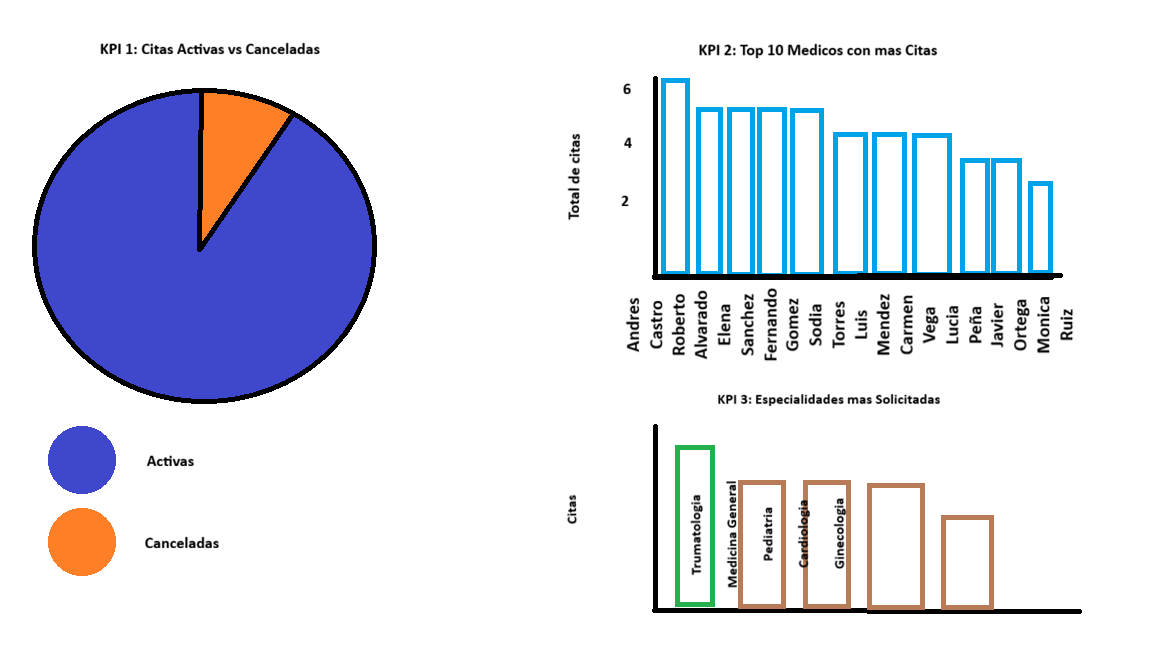

## Paso 2.1: Mapeo de Entidades y Atributos

Nuestro TPS guarda los datos en 3 archivos de texto separados por |

**data_medicos.txt** — guarda la informacion de cada medico
- codigo, nombre, edad, especialidad, horario, contrasena

**data_pacientes.txt** — guarda la informacion de cada paciente
- cedula, nombre, edad, telefono, contrasena

**data_citas.txt** — guarda cada cita registrada en el sistema
- id, cedulaPaciente, codigoMedico, fecha, motivo, estado

**Como se relacionan:**
- Una cita pertenece a un paciente usando la cedula
- Una cita pertenece a un medico usando el codigo del medico

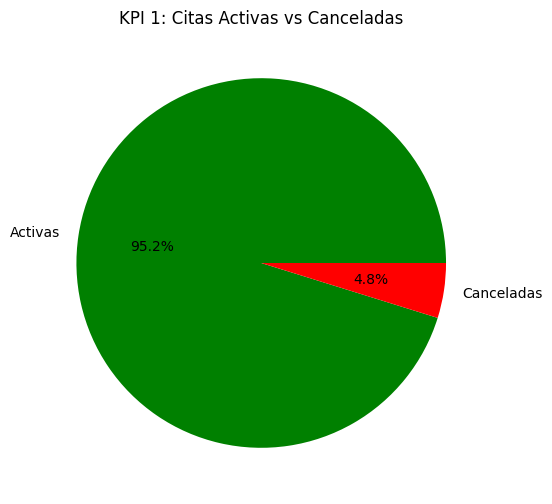

Total citas: 250
Activas: 238
Canceladas: 12


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar los datos de citas del TPS
dataCitas = pd.read_csv('data_citas.txt', sep='|', names=['id','cedulaPaciente','codigoMedico','fecha','motivo','estado'])

# Contar cuantas citas estan activas y cuantas canceladas
citasActivas = len(dataCitas[dataCitas['estado'] == 0])
citasCanceladas = len(dataCitas[dataCitas['estado'] == 1])

# Mostrar grafico de pastel
plt.figure(figsize=(6,6))
plt.pie([citasActivas, citasCanceladas], labels=['Activas', 'Canceladas'], autopct='%1.1f%%', colors=['green', 'red'])
plt.title('KPI 1: Citas Activas vs Canceladas')
plt.show()

print("Total citas:", len(dataCitas))
print("Activas:", citasActivas)
print("Canceladas:", citasCanceladas)

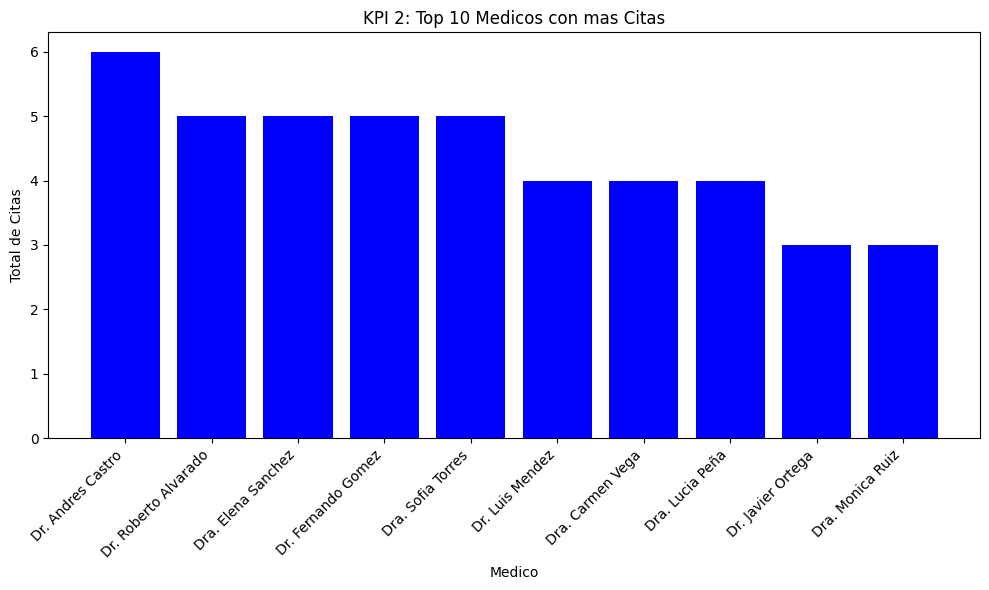

In [ ]:
# Cargar datos de medicos
dataMedicos = pd.read_csv('data_medicos.txt', sep='|', names=['codigo','nombre','edad','especialidad','horario','contrasena'])

# Contar cuantas citas tiene cada medico
citasPorMedico = dataCitas.groupby('codigoMedico').size().reset_index(name='totalCitas')

# Combinar con nombres de medicos
citasPorMedico = citasPorMedico.merge(dataMedicos[['codigo','nombre']], left_on='codigoMedico', right_on='codigo')

# Tomar los 10 medicos con mas citas
top10Medicos = citasPorMedico.nlargest(10, 'totalCitas')

# Mostrar grafico de barras horizontal
plt.figure(figsize=(10,6))
plt.bar(top10Medicos['nombre'], top10Medicos['totalCitas'], color='blue')
plt.xlabel('Medico')
plt.ylabel('Total de Citas')
plt.title('KPI 2: Top 10 Medicos con mas Citas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

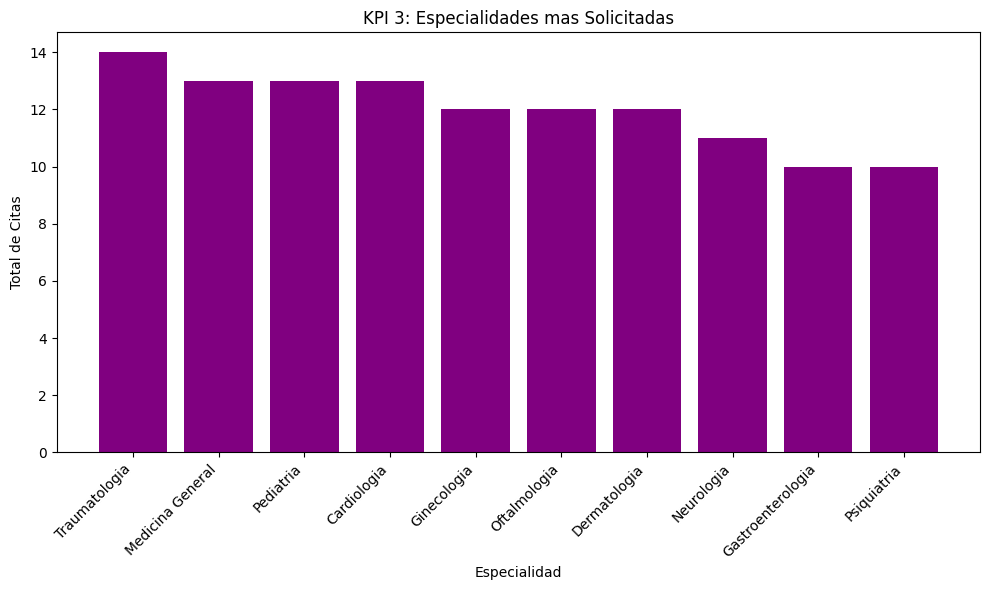

In [ ]:
# Combinar citas con medicos para obtener la especialidad
citasConEspecialidad = dataCitas.merge(dataMedicos[['codigo','especialidad']], left_on='codigoMedico', right_on='codigo')

# Contar citas por especialidad
citasPorEspecialidad = citasConEspecialidad.groupby('especialidad').size().reset_index(name='totalCitas')

# Ordenar de mayor a menor y tomar las 10 primeras
top10Especialidades = citasPorEspecialidad.sort_values('totalCitas', ascending=False).head(10)

# Mostrar grafico de barras
plt.figure(figsize=(10,6))
plt.bar(top10Especialidades['especialidad'], top10Especialidades['totalCitas'], color='purple')
plt.xlabel('Especialidad')
plt.ylabel('Total de Citas')
plt.title('KPI 3: Especialidades mas Solicitadas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Paso 4.1: Matriz de Atributos de Valor

**KPI 1 - Cancelaciones**
- Simplicidad: El grafico de pastel es facil de leer para cualquier persona
- Oportunidad: Se calcula al instante cuando se carga el archivo
- Accesibilidad: Cualquier persona entiende el porcentaje sin conocimientos tecnicos

**KPI 2 - Carga de medicos**
- Simplicidad: Las barras permiten comparar facilmente entre medicos
- Oportunidad: Se actualiza cada vez que se agrega una cita nueva
- Accesibilidad: Los nombres de los medicos hacen la grafica intuitiva

**KPI 3 - Especialidades**
- Simplicidad: Se ve claramente cual especialidad tiene mas demanda
- Oportunidad: Refleja en tiempo real la demanda del sistema
- Accesibilidad: Las especialidades son terminos conocidos para el personal

## Paso 4.2: Interpretacion Gerencial

**KPI 1 — Cancelaciones**
Si las cancelaciones superan el 20% del total de citas, el hospital deberia
enviar recordatorios a los pacientes antes de su cita para reducir ese numero.

**KPI 2 — Carga de medicos**
Si un medico tiene muchas mas citas que los demas, se le podria asignar
un asistente o repartir sus pacientes con otro medico de la misma especialidad.

**KPI 3 — Especialidades**
Si una especialidad tiene mucha mas demanda que las otras, el hospital
deberia contratar mas medicos de esa area para no dejar pacientes sin atencion.